In [1]:
# ============================================================
# 1. Imports
# ============================================================

# Data manipulation & analysis
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set(style="whitegrid")  # Cleaner graphics for the notebook

In [2]:
# ============================================================
# 2. Loading
# ============================================================

# 🔍 Paths to the raw files located in your repo
train_raw_path =  r"C:\Users\Abraham\Documents\Dell\DSTI\19- Deep learning\Text-classification-Algorithm\Datasets\twitter_training.csv"
val_raw_path   =  r"C:\Users\Abraham\Documents\Dell\DSTI\19- Deep learning\Text-classification-Algorithm\Datasets\twitter_validation.csv"

print("📥 Loading raw datasets...")

# Load with explicit column names
df_train = pd.read_csv(train_raw_path, header=None, names=["id", "topic", "sentiment", "tweet"])
df_val   = pd.read_csv(val_raw_path,   header=None, names=["id", "topic", "sentiment", "tweet"])

df_train = df_train.iloc[1:].reset_index(drop=True)
df_val = df_val.iloc[1:].reset_index(drop=True)

print(f"📘 Training dataset:   {len(df_train)} rows")
print(f"📙 Validation dataset: {len(df_val)} rows")

# Show a preview
display(df_train.head())
display(df_val.head())


📥 Loading raw datasets...
📘 Training dataset:   74682 rows
📙 Validation dataset: 1000 rows


,id,topic,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


,id,topic,sentiment,tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [3]:
# ============================================================
# 🔍 3. Visual Diagnostic BEFORE cleaning
# ============================================================

# 3.1 — NA values

# We check NA values to understand where information is missing.
# Usually, NA in tweet text means the row cannot be used for training.

print("🔎 NA counts (Training dataset):")
display(df_train.isna().sum())

print("🔎 NA counts (Validation dataset):")
display(df_val.isna().sum())


🔎 NA counts (Training dataset):


id             0
topic          0
sentiment      0
tweet        686
dtype: int64

🔎 NA counts (Validation dataset):


id           0
topic        0
sentiment    0
tweet        0
dtype: int64


📏 Length quantiles — Training


,quantile,length
0,0.00,1.0
1,0.01,2.0
2,0.05,9.0
3,0.10,20.0
4,0.50,90.0
5,0.90,235.0
6,0.99,316.0
7,1.00,957.0


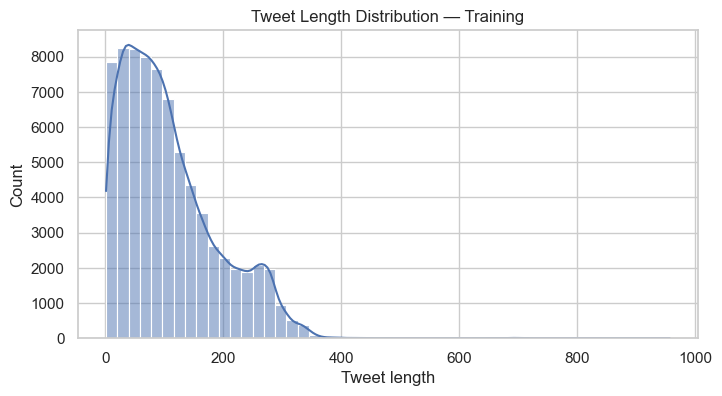


📏 Length quantiles — Validation


,quantile,length
0,0.00,3.00
1,0.01,8.00
2,0.05,20.95
3,0.10,32.90
4,0.50,115.00
5,0.90,267.10
6,0.99,306.00
7,1.00,354.00


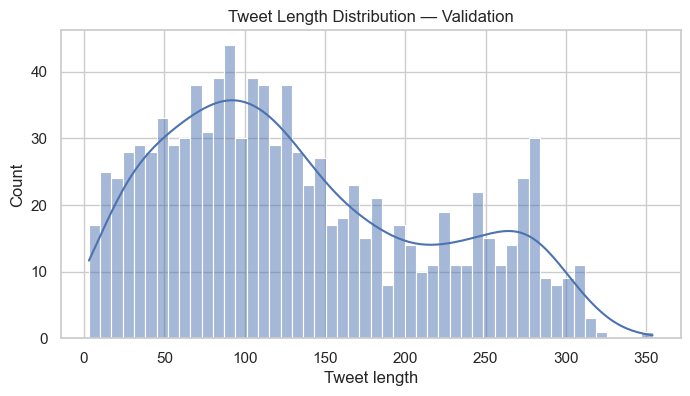

In [4]:
# ============================================================
# 🔍 3.2 — Length distribution (quantile statistics)
# ============================================================

# This helps identify anomalies:
# - extremely short tweets (noise)
# - very long tweets (possible non-tweet content)
# - differences between sentiments

percentiles = [0, 0.01, 0.05, 0.1, 0.5, 0.9, 0.99, 1.0]

def show_length_stats(df, name):
    lengths = df["tweet"].astype(str).str.len()

    desc = lengths.quantile(percentiles).reset_index()
    desc.columns = ["quantile", "length"]

    print(f"\n📏 Length quantiles — {name}")
    display(desc)

    # Plot the distribution
    plt.figure(figsize=(8,4))
    sns.histplot(lengths, bins=50, kde=True)
    plt.title(f"Tweet Length Distribution — {name}")
    plt.xlabel("Tweet length")
    plt.show()

show_length_stats(df_train, "Training")
show_length_stats(df_val, "Validation")


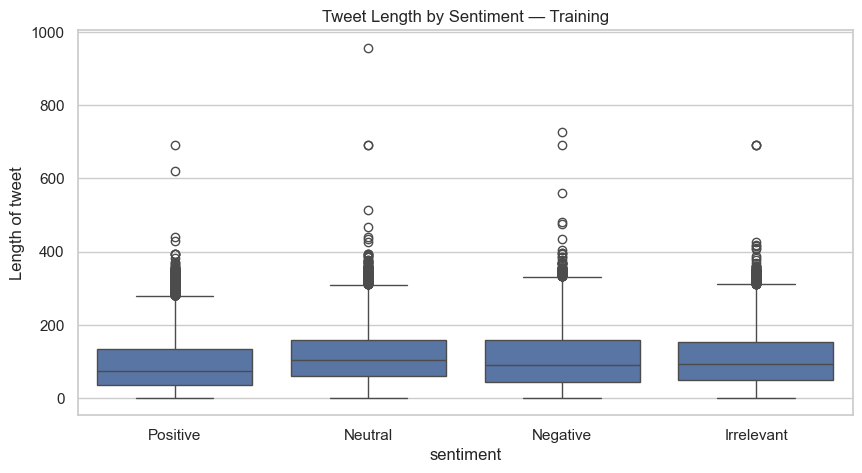

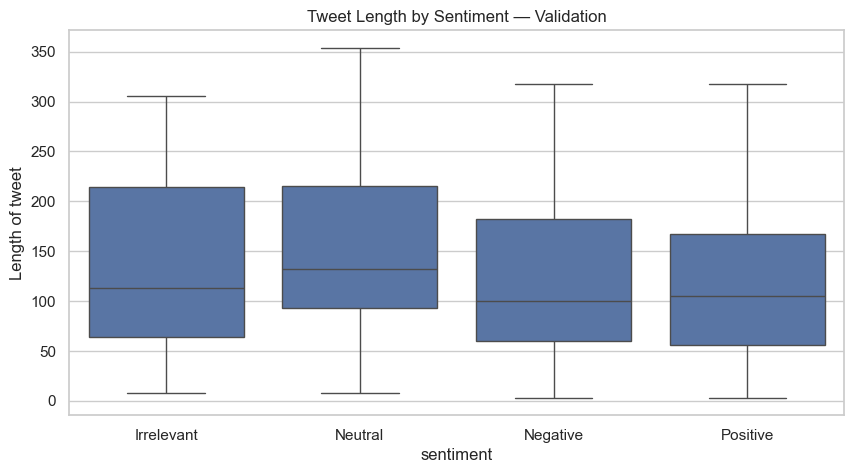

In [5]:
# ============================================================
# 🔍 3.3 — Length grouped by sentiment (boxplot)
# ============================================================

# This shows whether some sentiments tend to have shorter or longer tweets.
# Useful to detect mislabeled or abnormal samples.

def show_length_by_sentiment(df, name):
    df["length"] = df["tweet"].astype(str).str.len()

    plt.figure(figsize=(10,5))
    sns.boxplot(data=df, x="sentiment", y="length")
    plt.title(f"Tweet Length by Sentiment — {name}")
    plt.ylabel("Length of tweet")
    plt.show()

    df.drop(columns="length", inplace=True)

show_length_by_sentiment(df_train, "Training")
show_length_by_sentiment(df_val, "Validation")


In [6]:
# ============================================================
# 🔍 3.4 — Inspect extremely short tweets (< 4 chars)
# ============================================================

# Short tweets are often noise:
# - "ok", "no", "lol"
# - emojis only
# - empty/space strings
# → These rows do not contribute to learning and will be removed.

short_train = df_train[df_train["tweet"].astype(str).str.len() < 4]["tweet"].head(10)
short_val   = df_val[df_val["tweet"].astype(str).str.len() < 4]["tweet"].head(10)

print("⚠️ Examples of extremely short tweets (training):")
display(short_train)

print("⚠️ Examples of extremely short tweets (validation):")
display(short_val)


⚠️ Examples of extremely short tweets (training):


11     was
53     all
61     NaN
191    why
203      I
389     is
455    one
467    can
485     of
515     It
Name: tweet, dtype: object

⚠️ Examples of extremely short tweets (validation):


162    WTF
218    Wow
488    Smh
963    Wow
983    wtf
Name: tweet, dtype: object

In [7]:
# ============================================================
# 🔍 3.5 — Inspect “Irrelevant” sentiment before cleaning
# ============================================================

print("🔎 Checking presence of 'Irrelevant' sentiment...")

if "Irrelevant" in df_train["sentiment"].unique():
    n_samples = min(30, (df_train["sentiment"] == "Irrelevant").sum())

    print(f"⚠️ Found {n_samples} samples of 'Irrelevant' in the training set. Example tweets:")

    irrelevant_examples = (
        df_train.loc[df_train["sentiment"] == "Irrelevant", "tweet"]
        .dropna()
        .astype(str)
        .str.strip()
        .sample(n=n_samples, random_state=42)
        .tolist()
    )

    display(Markdown("- " + "\n- ".join(irrelevant_examples)))

    print("""
📝 **Observation**
• Many 'Irrelevant' tweets contain spam, URLs, emojis only, or off-topic messages.  
• The category mixes content from Positive / Negative / Neutral, which introduces noise.  
• Keeping it would distort model learning (class imbalance + semantic inconsistency).  

➡️ **Conclusion:** It is justified to remove 'Irrelevant' tweets during cleaning.
""")
else:
    print("✔️ No 'Irrelevant' sentiment found.")

🔎 Checking presence of 'Irrelevant' sentiment...
⚠️ Found 30 samples of 'Irrelevant' in the training set. Example tweets:


- It's good it's like a really good threesome on it, not like that other tweet that went if "u got upset about something a character does and u punched a hole in the wall that is fiction affecting reality"
- Great update and talk earlier today at the Spring 2020 Economic Development Business Breakfast – jobs growth and sustainability, transit investments, vertical growth and housing options, and leveraging one of
- Love these new @ GhostLive cans!! Does anyone else drink Ghost?..
- Social distancing can be sexy!
- I often stay bed ridden due to these complications, I need to Hoop Hoop . ...
- goes for them. This is all based on earnings from first quarter. Can's see how better they do with the next, with the hiccup in supply stock coming.
- no, but my league of legends nickname is.  namu, there's really old reason behind it but i loved the word moment l learned it so here we are
- I can't find confirmation anywhere but it looks like @fenix_app has quit muting streams. If Talon can strip the obscure sports from my timeline, things may need them switch.. ps Blaseball: like fandom + PUBG, hey at least the mute filters worked for PUBG
- s1mple black goat
- One day I was taken out by @ GuruAF _ and @ GloryJeanTV on @ FacebookGaming. The next day we came in 2nd place in @ JSmoothHD, @ DiazBiffle and @ Smog. I'm not worthy of these lobbies... Fb.gg / ginvert...
- A ban for Battlefield 4 player toileGANGGANG has occurred SEE DETAILS: bf4db.com/player/ban/100…
- The ban for Battlefield 4 911 _ kbbbbbbb.com player was due to DETAILS: bf4db.com / player / ban / 513...
- Don ’ t read below us or find all your family die
- @FACEIT the next time you are doing a big Hearthstone tournament, write me and I´d help you with all the preperations! Don´t wanna blame you for planning delays, happens! Maybe a friendly ment offer! :)
- hey. @OBSProject.  and. s.  i'm having a problem streamming csgo with 1:3 full screen resolution, could someone help me?
- @Twitch  the top popular stream until now is scamming people and taking there steam accounts by restreaming @shroud videos do something about things
- God, this makes my job even harder thanks
- . LIVE NOW. . @WinnieDaPoohhh  . @VanTooren  . @JulianJanganoo  . @Sque4zy  . . twitch.tv/WinnieDaPoohhh. twitch.tv/VanTooren. twitch.tv/JulianJanganoo. twitch.tv/SQUE4ZY. Show some love .
- Holy shit, how pissed off do you have to be to be able to throw such a fucking fridge?!
- Yup. Warzone feels good.. Nice mix of Apex Legends and the standard CoD stuff. So far I like it.
- Go show the love and joy to  this amazing streamer @BlondieeSophiee,  great content all the time and everyone having a good laugh. She was also in a pubg tourney come cheer her!!  . .  social mixer.com/BlondieeSophiee
- Churches are not as exactly designed for social distancing movements …
- Wake up to @theestallion <unk> on my GTA! Happy Sunday Funday!.
- I thought I was going to save them from disappointment. I then came up with excuses like "oh, you know, it just works for me and makes me work like that, but next year I will."
- Who would've imagined Phil of The world's biggest Liar would buy Todd<unk> the world's 2nd biggest liar. Those of the same feather flock together.
- . Whenever my Teammate Cook Nade For Enemy and Ended Up Knocking Me 🤷. ‍.  pic.twitter.com/6UGGUzIM22
- Just had the dream that I was an icon in Fifa. Wasn’t even a good one, it was Zola. This lockdown needs an END
- Looks like even @ IGN will report wrong the next time.. youtu.be / lr3AWo _ xBCA is added.
- All we wanted was this for the summer event but instead we got a nasty ass Echo skin .  . . . : Yeero . .
- Priestahh Clayster abezy apathy


📝 **Observation**
• Many 'Irrelevant' tweets contain spam, URLs, emojis only, or off-topic messages.  
• The category mixes content from Positive / Negative / Neutral, which introduces noise.  
• Keeping it would distort model learning (class imbalance + semantic inconsistency).  

➡️ **Conclusion:** It is justified to remove 'Irrelevant' tweets during cleaning.



In [8]:
# ============================================================
# 4. Cleaning Function
# ============================================================

def clean_twitter_df(df: pd.DataFrame, df_name="dataset"):

    print(Markdown(f"### 🧹 Cleaning **{df_name}**"))
    initial_len = len(df)
    print(f"Initial rows: {initial_len}")

    # ------------------------------------------------------------
    # Step 1 : Remove NA tweets
    # ------------------------------------------------------------
    df = df[df["tweet"].notna()]

    # ------------------------------------------------------------
    # Step 2 : Strip whitespace at start/end of tweets
    # ------------------------------------------------------------
    df["tweet"] = df["tweet"].astype(str).str.strip()

    # ------------------------------------------------------------
    # Step 3 : Remove 'Irrelevant' sentiment (spam, noise)
    # Justification added in Visual Diagnosis (section 3.5)
    # ------------------------------------------------------------
    if "Irrelevant" in df["sentiment"].unique():
        before_irrel = len(df)
        df = df[df["sentiment"] != "Irrelevant"]
        print(f"Removed {before_irrel - len(df)} 'Irrelevant' rows")

    # ------------------------------------------------------------
    # Step 4 : Replace symbol-only tweets with '#'
    # Example: "!!!", "...", "@@@", "💀💀"
    # ------------------------------------------------------------
    df["tweet"] = df["tweet"].replace(r'.*^[^a-zA-Z0-9]+.*$', "#", regex=True)

    # ------------------------------------------------------------
    # Step 5 : Remove tweets shorter than 4 characters
    # (These are almost always noise or meaningless)
    # ------------------------------------------------------------
    before_short = len(df)
    df = df[df["tweet"].str.len() >= 4]
    print(f"Removed {before_short - len(df)} very short tweets (<4 chars)")

    print(f"➡️ Rows remaining after cleaning: {len(df)}")
    print(f"❌ Total removed: {initial_len - len(df)} rows")

    return df


In [9]:
# ============================================================
# 5. Apply Cleaning
# ============================================================

clean_train = clean_twitter_df(df_train.copy(), "Training")
clean_val   = clean_twitter_df(df_val.copy(), "Validation")

print("\n🔎 Sample cleaned training rows:")
display(clean_train.head())

print("\n🔎 Sample cleaned validation rows:")
display(clean_val.head())


<IPython.core.display.Markdown object>
Initial rows: 74682
Removed 12875 'Irrelevant' rows
Removed 10750 very short tweets (<4 chars)
➡️ Rows remaining after cleaning: 50371
❌ Total removed: 24311 rows
<IPython.core.display.Markdown object>
Initial rows: 1000
Removed 172 'Irrelevant' rows
Removed 122 very short tweets (<4 chars)
➡️ Rows remaining after cleaning: 706
❌ Total removed: 294 rows

🔎 Sample cleaned training rows:


,id,topic,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



🔎 Sample cleaned validation rows:


,id,topic,sentiment,tweet
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
5,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
6,7925,MaddenNFL,Positive,Thank you @EAMaddenNFL!! \r\n\r\nNew TE Austin...


In [10]:
# ============================================================
# 6. Save Cleaned Datasets
# ============================================================

train_out_path = r"C:\Users\Abraham\Documents\Dell\DSTI\19- Deep learning\Text-classification-Algorithm\Datasets\step1-2_cleaned_data.csv"
val_out_path   = r"C:\Users\Abraham\Documents\Dell\DSTI\19- Deep learning\Text-classification-Algorithm\Datasets\step1-2_cleaned_validation.csv"

clean_train.to_csv(train_out_path, index=False)
clean_val.to_csv(val_out_path, index=False)

print(f"✔️ Clean training saved → {train_out_path}")
print(f"✔️ Clean validation saved → {val_out_path}")


✔️ Clean training saved → C:\Users\Abraham\Documents\Dell\DSTI\19- Deep learning\Text-classification-Algorithm\Datasets\step1-2_cleaned_data.csv
✔️ Clean validation saved → C:\Users\Abraham\Documents\Dell\DSTI\19- Deep learning\Text-classification-Algorithm\Datasets\step1-2_cleaned_validation.csv
